Figura guardada como: superficie_F_x_p_cuadratica.png


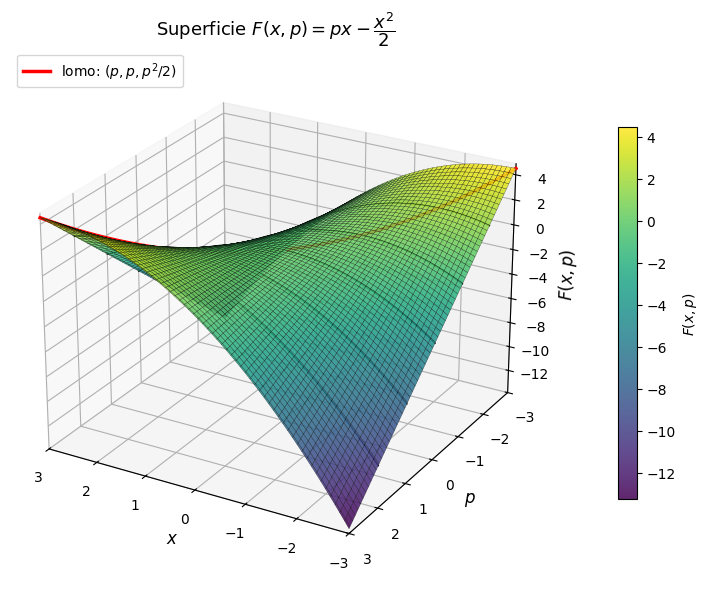

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D en algunos entornos

# ---------------------------
# Parámetros de la gráfica
# ---------------------------
x_min, x_max = -3.0, 3.0
p_min, p_max = -3.0, 3.0
n_grid = 200   # resolución de la malla (sube/baja si quieres más/menos detalle)

# ---------------------------
# Malla y función F(x,p)
# ---------------------------
x = np.linspace(x_min, x_max, n_grid)
p = np.linspace(p_min, p_max, n_grid)
X, P = np.meshgrid(x, p)

F = P * X - X**2 / 2.0   # F(x,p) = p x - x^2/2

# ---------------------------
# Figura 3D
# ---------------------------
fig = plt.figure(figsize=(8, 6), dpi=100)
ax = fig.add_subplot(111, projection="3d")

# Superficie
surf = ax.plot_surface(
    X, P, F,
    cmap="viridis",
    alpha=0.85,
    rstride=3,
    cstride=3,
    linewidth=0.2,
    edgecolor="k"
)

# Curvas de corte para p fijo (parábolas en x)
p_values = [-2, -1, 0, 1, 2]
for p0 in p_values:
    x_line = np.linspace(x_min, x_max, 400)
    F_line = p0 * x_line - x_line**2 / 2.0
    ax.plot(
        x_line,
        np.full_like(x_line, p0),
        F_line,
        color="black",
        linewidth=1.0
    )

# Curva de máximos: (x,p,F) = (p,p,p^2/2)
t = np.linspace(x_min, x_max, 400)
F_ridge = t**2 / 2.0
ax.plot(
    t, t, F_ridge,
    color="red",
    linewidth=2.5,
    label=r"lomo: $(p,p,p^2/2)$"
)

# ---------------------------
# Estética del eje y vista
# ---------------------------
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel(r"$p$", fontsize=12)
ax.set_zlabel(r"$F(x,p)$", fontsize=12)

ax.set_xlim(x_min, x_max)
ax.set_ylim(p_min, p_max)

# Vista tipo GeoGebra (ajusta ángulos si quieres)
ax.view_init(elev=25, azim=120)

# Barra de color
fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label=r"$F(x,p)$")

# Título opcional
ax.set_title(r"Superficie $F(x,p)=px-\dfrac{x^{2}}{2}$", fontsize=13)

# Leyenda (solo para el lomo rojo)
ax.legend(loc="upper left")

plt.tight_layout()

# ---------------------------
# Guardar como PNG de alta resolución
# ---------------------------
output_file = "superficie_F_x_p_cuadratica.png"
fig.savefig(output_file, dpi=600, bbox_inches="tight")
print(f"Figura guardada como: {output_file}")


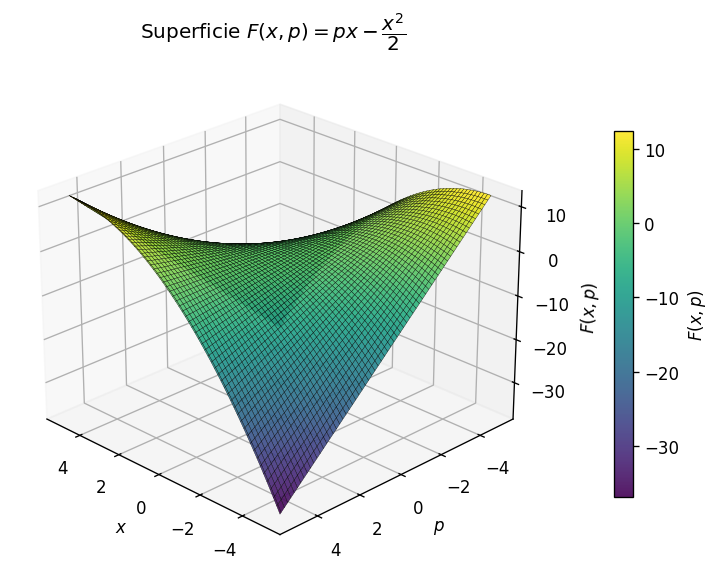

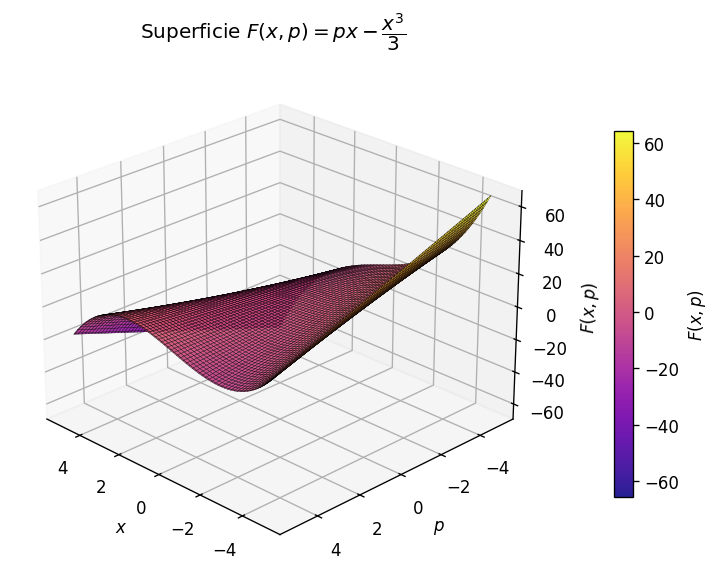

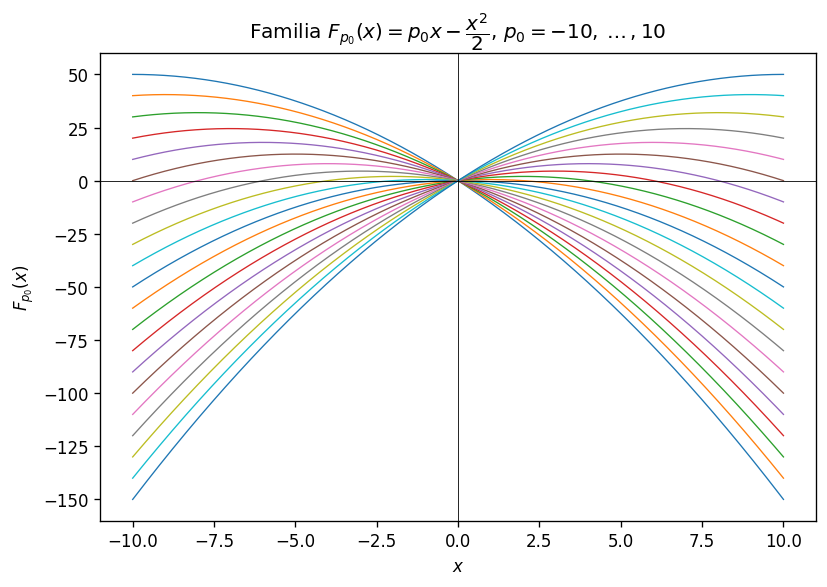

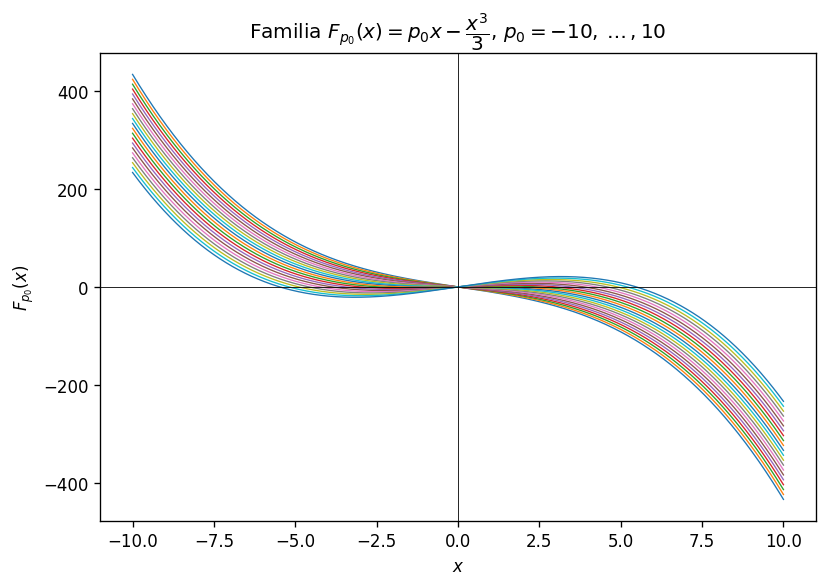

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D en algunos entornos

# ============================================================
#  Funciones
# ============================================================

def F_quad(x, p):
    return p * x - x**2 / 2.0

def F_cubic(x, p):
    return p * x - x**3 / 3.0

# Rango común
x_min, x_max = -5, 5
p_min, p_max = -5, 5
n_grid = 200  # resolución de malla para las superficies

# Malla 2D para las superficies
x = np.linspace(x_min, x_max, n_grid)
p = np.linspace(p_min, p_max, n_grid)
X, P = np.meshgrid(x, p)

# ============================================================
# (a) Superficie 3D F(x,p) = p x - x^2/2
# ============================================================

F1 = F_quad(X, P)

fig1 = plt.figure(figsize=(7, 5), dpi=120)
ax1 = fig1.add_subplot(111, projection="3d")

surf1 = ax1.plot_surface(
    X, P, F1,
    cmap="viridis",
    rstride=3,
    cstride=3,
    linewidth=0.2,
    edgecolor="k",
    alpha=0.9
)

ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$p$")
ax1.set_zlabel(r"$F(x,p)$")
ax1.set_title(r"Superficie $F(x,p)=px-\dfrac{x^{2}}{2}$")

ax1.view_init(elev=25, azim=135)  # ángulo de vista razonable

fig1.colorbar(surf1, ax=ax1, shrink=0.7, pad=0.1, label=r"$F(x,p)$")
plt.tight_layout()
fig1.savefig("F_quadratic_surface.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# (a) Superficie 3D F(x,p) = p x - x^3/3
# ============================================================

F2 = F_cubic(X, P)

fig2 = plt.figure(figsize=(7, 5), dpi=120)
ax2 = fig2.add_subplot(111, projection="3d")

surf2 = ax2.plot_surface(
    X, P, F2,
    cmap="plasma",
    rstride=3,
    cstride=3,
    linewidth=0.2,
    edgecolor="k",
    alpha=0.9
)

ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$p$")
ax2.set_zlabel(r"$F(x,p)$")
ax2.set_title(r"Superficie $F(x,p)=px-\dfrac{x^{3}}{3}$")

ax2.view_init(elev=25, azim=135)

fig2.colorbar(surf2, ax=ax2, shrink=0.7, pad=0.1, label=r"$F(x,p)$")
plt.tight_layout()
fig2.savefig("F_cubic_surface.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# (b) Familia de funciones F_{p0}(x) = p0 x - x^2/2
#      para p0 = -10, ..., 10  (21 funciones)
# ============================================================

x_line = np.linspace(-10, 10, 2000)
p_values = np.arange(-10, 11, 1)  # -10, -9, ..., 10

plt.figure(figsize=(7, 5), dpi=120)

for p0 in p_values:
    Fp = F_quad(x_line, p0)
    plt.plot(x_line, Fp, linewidth=0.8)

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)

plt.xlabel(r"$x$")
plt.ylabel(r"$F_{p_0}(x)$")
plt.title(r"Familia $F_{p_0}(x)=p_0x-\dfrac{x^{2}}{2}$, $p_0=-10,\dots,10$")

plt.tight_layout()
plt.savefig("F_quadratic_family.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# (b) Familia de funciones F_{p0}(x) = p0 x - x^3/3
#      para p0 = -10, ..., 10
# ============================================================

plt.figure(figsize=(7, 5), dpi=120)

for p0 in p_values:
    Fp = F_cubic(x_line, p0)
    plt.plot(x_line, Fp, linewidth=0.8)

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)

plt.xlabel(r"$x$")
plt.ylabel(r"$F_{p_0}(x)$")
plt.title(r"Familia $F_{p_0}(x)=p_0x-\dfrac{x^{3}}{3}$, $p_0=-10,\dots,10$")

plt.tight_layout()
plt.savefig("F_cubic_family.png", dpi=600, bbox_inches="tight")
plt.show()
